# 🛡️ Análise Exploratória de Dados (EDA): Detecção de Fraude em Cartões de Crédito

**Autor:** Douglas Moura / DOCHMO Analytics  
**Dataset:** Credit Card Fraud Detection (Kaggle / ULB Machine Learning Group)  
**Objetivo:** Mapear os padrões comportamentais, temporais, financeiros e estatísticos de transações legítimas vs. fraudulentas em um cenário de **desbalanceamento severo** (~0,17% de fraudes).

---

## 🎯 Sumário Executivo do Estudo
1. **Visão Geral, Integridade dos Dados e Auditoria de Duplicatas**
2. **Diagnóstico do Desbalanceamento da Variável Alvo (`Class`)**
3. **Comportamento Temporal (`Time`) e Janelas de Vulnerabilidade**
4. **Comportamento Financeiro (`Amount`) e Perfil do Fraudador**
5. **Correlação Linear das Features Anonimizadas (`V1` a `V28`)**
6. **Dispersão Bivariada Conjunta e Não-Linearidade (`V14` × `V4`)**
7. **Diagnóstico de Outliers e Impacto nas Fraudes Reais**
8. **Diretrizes e Próximos Passos para a Modelagem Preditiva**


In [2]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde

# Configuração de caminhos para módulos auxiliares em src/
sys.path.append(os.path.abspath(".."))
from src.preprocessing import load_data
from src.outlier_detector import detect_outliers_iqr

print("[INFO] Ambiente e dependências carregados com sucesso.")


[INFO] Ambiente e dependências carregados com sucesso.


## 1. Visão Geral e Integridade dos Dados

O dataset reúne registros de transações efetuadas por cartões de crédito em setembro de 2013 por clientes europeus:
- Abrange transações realizadas ao longo de **dois dias consecutivos** (aproximadamente 48 horas).
- Possui **284.807 transações**, das quais apenas **492 são fraudulentas**.
- As variáveis de `V1` a `V28` representam componentes principais extraídos via **PCA (Principal Component Analysis)** para resguardar a privacidade e sigilo bancário dos usuários.
- As únicas features em escala original são `Time` (segundos decorridos desde a primeira transação) e `Amount` (valor monetário da operação).


In [ ]:
df = load_data("../data/creditcard.csv")
display(df.head())

[INFO] Carregando dados de: ../data/creditcard.csv
[INFO] Dataset carregado com sucesso: 284,807 linhas e 31 colunas.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("--- Informações Estruturais do Dataset ---")
print(f"Total de linhas (transações):  {df.shape[0]:,}")
print(f"Total de colunas (features):   {df.shape[1]}")
print(f"Valores nulos encontrados:     {df.isnull().sum().max()}")
print(f"Registros duplicados:          {df.duplicated().sum():,}")


--- Informações Estruturais do Dataset ---
Total de linhas (transações):  284,807
Total de colunas (features):   31
Valores nulos encontrados:     0
Registros duplicados:          1,081


### 🔍 Auditoria de Registros Duplicados e Risco de Data Leakage

Foram identificadas **1.081 linhas duplicadas excedentes** (1.854 linhas totais envolvidas em agrupamentos duplicados).  
Abaixo é avaliado a distribuição dessas duplicatas por classe para verificar o comportamento das repetições e discutir seu impacto na modelagem preditiva.


In [6]:
# Auditoria aprofundada de duplicatas por classe
dup_mask_all = df.duplicated(keep=False)
dup_mask_extra = df.duplicated(keep='first')

dup_summary = pd.DataFrame({
    'Ocorrências Extras (Dropáveis)': df[dup_mask_extra]['Class'].value_counts(),
    'Total de Linhas Envolvidas': df[dup_mask_all]['Class'].value_counts()
})
dup_summary.index = ['Legítimas (0)', 'Fraudes (1)']
display(dup_summary)

# Amostra das fraudes duplicadas para diagnóstico do padrão de ataque
fraud_duplicates = df[dup_mask_all & (df['Class'] == 1)][['Time', 'Amount', 'Class']].head(8)
print("--- Amostra de Transações Fraudulentas Idênticas (Ataques em Rajada) ---")
display(fraud_duplicates)


,Ocorrências Extras (Dropáveis),Total de Linhas Envolvidas
Legítimas (0),1062,1822
Fraudes (1),19,32


--- Amostra de Transações Fraudulentas Idênticas (Ataques em Rajada) ---


,Time,Amount,Class
102441,68207.0,1.0,1
102442,68207.0,1.0,1
102443,68207.0,1.0,1
102444,68207.0,1.0,1
102445,68207.0,1.0,1
102446,68207.0,1.0,1
141257,84204.0,0.0,1
141258,84204.0,0.0,1


**💡 Diagnóstico e Implicações Metodológicas:**
1. **Padrão de Ataque em Rajada (*Burst Attacks*):** As 19 fraudes duplicadas repetem os mesmos valores (frequentemente transações de teste de \$1,00 ou \$0,00) no exato mesmo segundo (`Time`), evidenciando bots automatizados testando credenciais clonadas.
2. **Risco Crítico de Data Leakage:** Se registros idênticos forem mantidos e distribuídos aleatoriamente entre Treino e Teste durante o *split*, o modelo será avaliado sobre instâncias que ele já memorizou no treino, inflando artificialmente o **Recall**.
3. **Decisão do Projeto:** É mantido o dataset íntegro nesta etapa exploratória para consistência com o benchmark clássico da literatura, garantindo que a separação de treino e teste no módulo de modelagem seja conduzida de forma consciente.


## 2. Diagnóstico do Desbalanceamento da Variável Alvo (`Class`)

Em problemas de detecção de anomalias financeiras, o desbalanceamento não é apenas um detalhe técnico: é o cerne do desafio de negócio.
- **Classe 0:** Transações Legítimas (Majoritária)
- **Classe 1:** Transações Fraudulentas (Minoritária)

Métricas ingênuas como **Acurácia** são completamente ilusórias aqui: um modelo "néscio" que sempre prevê `0` alcançaria **99.83% de acurácia**, mas deixaria passar 100% dos prejuízos por fraude!


In [7]:
# Cálculo das frequências e proporções da variável alvo
counts = df['Class'].value_counts()
pcts = df['Class'].value_counts(normalize=True) * 100

# Formatação numérica no padrão PT-BR
str_c0 = f"{counts[0]:_}".replace('_', '.')
str_c1 = f"{counts[1]:_}".replace('_', '.')
str_p0 = f"{pcts[0]:.3f}".replace('.', ',')
str_p1 = f"{pcts[1]:.3f}".replace('.', ',')
str_taxa = f"{round(counts[0] / counts[1]):_}".replace('_', '.')

print(f"Transações Legítimas (0): {str_c0} ({str_p0}%)")
print(f"Transações Fraude    (1): {str_c1} ({str_p1}%)")
print(f"Taxa de Desbalanceamento: 1 fraude para cada {str_taxa} transações legítimas.")
print()

# Estruturação para os gráficos
class_counts = df['Class'].value_counts().reset_index()
class_counts.columns = ['Class', 'Count']
class_counts['Class_Name'] = class_counts['Class'].map({0: 'Legítima', 1: 'Fraude'})


Transações Legítimas (0): 284.315 (99,827%)
Transações Fraude    (1): 492 (0,173%)
Taxa de Desbalanceamento: 1 fraude para cada 578 transações legítimas.



In [10]:
# Gráfico de Barras com contagem em escala logarítmica
fig_bar = px.bar(
    class_counts, 
    x='Class_Name', 
    y='Count', 
    title="Contagem de Transações por Classe (Escala Log)",
    color='Class_Name',
    color_discrete_map={'Legítima': "#E2E8F0", 'Fraude': "#E53E3E"}
)

fig_bar.for_each_trace(
    lambda trace: trace.update(
        marker_line_color="#D4AF37",
        marker_line_width=1.5
    )
)

fig_bar.update_traces(
    textposition="outside",
    texttemplate="%{y:,.0f}",
    hovertemplate="<b>%{x}</b><br>Quantidade: %{y:,.0f} transações<extra></extra>"
)

fig_bar.update_layout(
    separators=",.",
    title=dict(x=0.5, font=dict(size=22, family="Arial", color="#E2E8F0")),
    margin=dict(t=50, b=30, l=60, r=40),
    xaxis_title="",
    yaxis_title="Quantidade (Escala Logarítmica)",
    font=dict(family="Arial", size=14, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    showlegend=False,
    xaxis=dict(showgrid=False, color="#E2E8F0"),
    yaxis=dict(
        type="log",
        dtick=1,
        exponentformat="power",
        showgrid=True, 
        gridcolor="#1E293B", 
        color="#E2E8F0"
    )
)

fig_bar.show()


In [11]:
# Gráfico de Proporção Relativa
fig_pie = go.Figure(data=[go.Pie(
    labels=['Legítimas', 'Fraudes'],
    values=[counts[0], counts[1]],
    pull=[0, 0.25],
    marker=dict(
        colors=["#E2E8F0", "#E53E3E"],
        line=dict(color=["#D4AF37", "#D4AF37"], width=1.0)
    )
)])

fig_pie.update_traces(
    textposition='inside',
    textinfo='percent+label',
    hovertemplate="<b>%{label}</b><br>Quantidade: %{value:,.0f}<br>Proporção: %{percent}<extra></extra>",
    textfont=dict(family="Arial", size=14, color="#0B1320")
)

fig_pie.update_layout(
    separators=",.",
    title=dict(text="Proporção Real na Base de Dados", x=0.5, font=dict(size=22, family="Arial", color="#E2E8F0")),
    font=dict(family="Arial", size=14, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    showlegend=True,
    legend=dict(
        x=0.7,
        y=0.2,
        xanchor="left",
        yanchor="middle",
        font=dict(family="Arial", size=14, color="#E2E8F0"),
        bgcolor="rgba(0,0,0,0)"
    ),
    margin=dict(t=80, b=40, l=40, r=40)
)

fig_pie.show()


## 3. Comportamento Temporal (`Time`) e Janelas de Vulnerabilidade

A variável `Time` registra os segundos decorridos desde a primeira transação da base. O período total cobre aproximadamente 48 horas (172.800 segundos).

Vamos converter essa métrica para a **hora do dia (0 a 24h)** através da operação matemática de módulo `(Time / 3600) % 24`, permitindo identificar se existem janelas de horário onde os fraudadores atuam com maior frequência relativa.


In [18]:
# Conversão temporal em horas (ciclo de 24h)
df_temp = df.copy()
df_temp['Hour'] = (df_temp['Time'] / 3600) % 24

df_legit = df_temp[df_temp['Class'] == 0]

# Gráfico de transações legítimas
fig_legit_time = go.Figure()

fig_legit_time.add_trace(
    go.Histogram(
        x=df_legit['Hour'],
        nbinsx=24,
        histnorm='density',
        name='Legítima',
        marker=dict(
            color='#E2E8F0',
            line=dict(color='#D4AF37', width=1.0)
        ),
        hovertemplate="<b>Faixa:</b> %{x:.0f}h<br><b>Densidade:</b> %{y:.0f}<extra></extra>"
    )
)

fig_legit_time.update_layout(
    separators=",.",
    title=dict(
        text="Distribuição Horária das Transações Legítimas",
        x=0.5,
        font=dict(size=20, family="Arial", color="#E2E8F0")
    ),
    margin=dict(t=80, b=50, l=60, r=40),
    font=dict(family="Arial", size=13, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    showlegend=False
)

fig_legit_time.update_xaxes(
    title_text="Hora do Dia (0h - 24h)",
    range=[0, 24],
    dtick=2,
    showgrid=False,
    color="#E2E8F0"
)

fig_legit_time.update_yaxes(
    title_text="Densidade Estimada",
    showgrid=True,
    gridcolor="#1E293B",
    color="#E2E8F0"
)

fig_legit_time.show()

In [19]:
df_fraud = df_temp[df_temp['Class'] == 1]

# Gráfico de transações fraudulentas
fig_fraud_time = go.Figure()

fig_fraud_time.add_trace(
    go.Histogram(
        x=df_fraud['Hour'],
        nbinsx=24,
        histnorm='density',
        name='Fraude',
        marker=dict(
            color='#E53E3E',
            line=dict(color='#D4AF37', width=1.0)
        ),
        hovertemplate="<b>Faixa:</b> %{x:.0f}h<br><b>Densidade:</b> %{y:.0f}<extra></extra>"
    )
)

fig_fraud_time.update_layout(
    separators=",.",
    title=dict(
        text="Distribuição Horária das Transações Fraudulentas",
        x=0.5,
        font=dict(size=20, family="Arial", color="#E2E8F0")
    ),
    margin=dict(t=80, b=50, l=60, r=40),
    font=dict(family="Arial", size=13, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    showlegend=False
)

fig_fraud_time.update_xaxes(
    title_text="Hora do Dia (0h - 24h)",
    range=[0, 24],
    dtick=2,
    showgrid=False,
    color="#E2E8F0"
)

fig_fraud_time.update_yaxes(
    title_text="Densidade Estimada",
    showgrid=True,
    gridcolor="#1E293B",
    color="#E2E8F0"
)

fig_fraud_time.show()

del df_temp, df_legit, df_fraud

**💡 Insight Temporal:**  
As transações legítimas exibem uma curva circadiana típica do comportamento humano (queda expressiva na madrugada entre 1h e 6h e pico durante o dia e à noite).  
Em contrapartida, as **fraudes mantêm uma densidade elevada na madrugada**, período em que as vítimas demoram mais para perceber notificações de compras indevidas no celular.


## 4. Comportamento Financeiro (`Amount`) e Perfil do Fraudador

É analisado a distribuição dos valores financeiros transacionados por classe.  
Compreender as faixas de valores ajuda o negócio a estipular réguas de validação e estimar o valor financeiro em risco.


In [20]:
legit_amount = df[df['Class'] == 0]['Amount']
fraud_amount = df[df['Class'] == 1]['Amount']

def fmt_currency(val):
    return f"$ {val:,.2f}".replace(',', '_').replace('.', ',').replace('_', '.')

summary_amount = pd.DataFrame({
    'Métrica Estatística': [
        'Média', 
        'Mediana', 
        'Desvio Padrão', 
        'Valor Mínimo', 
        'Percentil 75 (Q3)', 
        'Valor Máximo', 
        'Soma Total em Risco/Movimentada'
    ],
    'Legítimas (0)': [
        fmt_currency(legit_amount.mean()),
        fmt_currency(legit_amount.median()),
        fmt_currency(legit_amount.std()),
        fmt_currency(legit_amount.min()),
        fmt_currency(legit_amount.quantile(0.75)),
        fmt_currency(legit_amount.max()),
        fmt_currency(legit_amount.sum())
    ],
    'Fraudes (1)': [
        fmt_currency(fraud_amount.mean()),
        fmt_currency(fraud_amount.median()),
        fmt_currency(fraud_amount.std()),
        fmt_currency(fraud_amount.min()),
        fmt_currency(fraud_amount.quantile(0.75)),
        fmt_currency(fraud_amount.max()),
        fmt_currency(fraud_amount.sum())
    ]
})

styled_summary = summary_amount.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1E293B'), ('color', '#E2E8F0'), ('font-family', 'Arial'), ('font-size', '14px'), ('text-align', 'center'), ('border', '1px solid #334155')]},
    {'selector': 'td', 'props': [('background-color', '#0B1320'), ('color', '#E2E8F0'), ('font-family', 'Arial'), ('font-size', '13px'), ('text-align', 'center'), ('border', '1px solid #1E293B')]},
    {'selector': 'caption', 'props': [('caption-side', 'top'), ('color', '#E2E8F0'), ('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding-bottom', '10px')]}
]).hide(axis='index').set_caption("Resumo dos Valores Transacionados (Amount)")

display(styled_summary)


Métrica Estatística,Legítimas (0),Fraudes (1)
Média,"$ 88,29","$ 122,21"
Mediana,"$ 22,00","$ 9,25"
Desvio Padrão,"$ 250,11","$ 256,68"
Valor Mínimo,"$ 0,00","$ 0,00"
Percentil 75 (Q3),"$ 77,05","$ 105,89"
Valor Máximo,"$ 25.691,16","$ 2.125,87"
Soma Total em Risco/Movimentada,"$ 25.102.462,04","$ 60.127,97"


In [21]:
# Cálculo da densidade em escala logarítmica
log_legit = np.log10(df[df['Class'] == 0]['Amount'] + 0.01)
log_fraud = np.log10(df[df['Class'] == 1]['Amount'] + 0.01)

x_range = np.linspace(min(log_legit.min(), log_fraud.min()), max(log_legit.max(), log_fraud.max()), 500)
kde_legit = gaussian_kde(log_legit)(x_range)
kde_fraud = gaussian_kde(log_fraud)(x_range)
x_real = 10**x_range

fig_amount_density = go.Figure()

fig_amount_density.add_trace(go.Scatter(
    x=x_real, 
    y=kde_legit,
    mode='lines', 
    name='Legítima (0)',
    line=dict(color='#E2E8F0', width=2.5),
    fill='tozeroy', 
    fillcolor='rgba(226, 232, 240, 0.15)',
    hovertemplate="Densidade: <b>%{y:.4f}</b><extra></extra>"
))

fig_amount_density.add_trace(go.Scatter(
    x=x_real, 
    y=kde_fraud,
    mode='lines', 
    name='Fraude (1)',
    line=dict(color='#E53E3E', width=2.5),
    fill='tozeroy', 
    fillcolor='rgba(229, 62, 62, 0.25)',
    hovertemplate="Densidade: <b>%{y:.3f}</b><extra></extra>"
))

fig_amount_density.update_layout(
    separators=",.",
    title=dict(
        text="Distribuição Comparativa do Valor das Transações (Amount)", 
        x=0.5, 
        font=dict(size=20, family="Arial", color="#E2E8F0")
    ),
    margin=dict(t=80, b=50, l=60, r=40),
    xaxis_title="Valor da Transação ($ - Escala Logarítmica)",
    yaxis_title="Densidade Estimada",
    font=dict(family="Arial", size=14, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    showlegend=True,
    legend=dict(x=0.82, y=0.95, font=dict(color="#E2E8F0"), bgcolor="rgba(0,0,0,0)"),
    xaxis=dict(
        type="log", 
        dtick=1,
        exponentformat="power", 
        showgrid=True, 
        gridcolor="#1E293B", 
        color="#E2E8F0"
    ),
    yaxis=dict(
        showgrid=True, 
        gridcolor="#1E293B", 
        color="#E2E8F0"
    ),
    hovermode="x unified",
    hoverlabel=dict(
        bgcolor="#1E293B",
        font_color="#E2E8F0",
        font_family="Arial",
        font_size=13,
        bordercolor="#D4AF37"
    )
)

fig_amount_density.show()

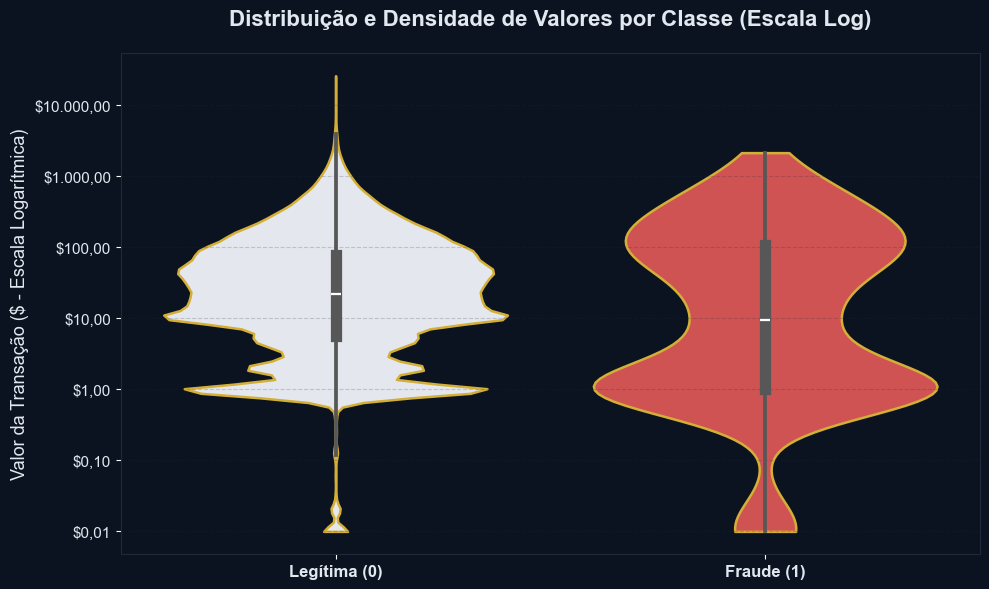

In [ ]:
# Violin Plot Comparativo com escala logarítmica
df_violin = df.copy()
df_violin['Class_Name'] = df_violin['Class'].map({0: 'Legítima (0)', 1: 'Fraude (1)'})
df_violin['Amount_Log'] = np.log10(df_violin['Amount'] + 0.01)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0B1320')
ax.set_facecolor('#0B1320')

palette = {'Legítima (0)': '#E2E8F0', 'Fraude (1)': '#E53E3E'}
sns.violinplot(
    data=df_violin,
    x='Class_Name',
    y='Amount_Log',
    hue='Class_Name',
    palette=palette,
    legend=False,
    inner='box',
    cut=0,
    linewidth=1.8,
    ax=ax
)

for patch in ax.collections:
    patch.set_edgecolor('#D4AF37')

ax.set_title("Distribuição e Densidade de Valores por Classe (Escala Log)", 
             fontsize=16, fontweight='bold', color='#E2E8F0', pad=20, family='Arial')
ax.set_xlabel("", fontsize=12)
ax.set_ylabel("Valor da Transação ($ - Escala Logarítmica)", fontsize=13, color='#E2E8F0', family='Arial')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Legítima (0)', 'Fraude (1)'], color='#E2E8F0', fontsize=12, fontweight='bold', family='Arial')

ticks = [-2, -1, 0, 1, 2, 3, 4]
labels = ['$0,01', '$0,10', '$1,00', '$10,00', '$100,00', '$1.000,00', '$10.000,00']
ax.set_yticks(ticks)
ax.set_yticklabels(labels, color='#E2E8F0', fontsize=11, family='Arial')

ax.yaxis.grid(True, linestyle='--', alpha=0.2, color='#1E293B')
ax.xaxis.grid(False)
for spine in ax.spines.values():
    spine.set_color('#1E293B')

plt.tight_layout()
plt.show()

del df_violin

**💡 Insight Financeiro:**  
Apesar de o valor máximo de fraude ter sido \$2.125,87, a mediana das fraudes é de apenas **\$9,25**, e 75% das fraudes custam menos de **\$105,89**.  
Isso demonstra o comportamento clássico de "card testing" (testar limites com pequenos valores) e fraudes frequentes de baixo tíquete para não disparar limites estáticos das bandeiras de cartão.


## 5. Correlação Linear das Componentes PCA (`V1` a `V28`) com `Class`

Como as variáveis de `V1` a `V28` resultam de uma transformação ortogonal (PCA), elas são estatisticamente descorrelacionadas entre si. No entanto, cada componente possui um grau diferente de associação linear com a variável alvo `Class`.


In [23]:
# Cálculo e ordenação das correlações de Pearson com Class
pca_cols = [f"V{i}" for i in range(1, 29)]
correlations = df[pca_cols + ['Class']].corr()['Class'].drop('Class').sort_values()

corr_df = correlations.reset_index()
corr_df.columns = ['Feature', 'Correlation']
corr_df['Direcao'] = corr_df['Correlation'].apply(lambda x: 'Positiva' if x > 0 else 'Negativa')

top_negative = correlations.head(5)
top_positive = correlations.tail(5)

print("--- TOP 5 CORRELAÇÕES NEGATIVAS MAIS FORTES ---")
for feat, val in top_negative.items():
    str_val = f"{val:.4f}".replace('.', ',')
    print(f"  • {feat:5s}: {str_val}")

print()
print("--- TOP 5 CORRELAÇÕES POSITIVAS MAIS FORTES ---")
for feat, val in top_positive.items():
    str_val = f"{val:.4f}".replace('.', ',')
    print(f"  • {feat:5s}: {str_val}")
print()

fig_corr = px.bar(
    corr_df,
    x='Correlation',
    y='Feature',
    orientation='h',
    title="Correlação Linear dos Componentes PCA com a Variável Fraude (Class)",
    color='Direcao',
    color_discrete_map={'Negativa': '#E53E3E', 'Positiva': '#E2E8F0'}
)

fig_corr.for_each_trace(
    lambda trace: trace.update(
        marker_line_color="#D4AF37",
        marker_line_width=0.7
    )
)

fig_corr.update_traces(
    hovertemplate="<b>Componente %{y}</b><br>Correlação: <b>%{x:,.4f}</b><extra></extra>"
)

fig_corr.update_layout(
    separators=",.",
    title=dict(x=0.5, font=dict(size=20, family="Arial", color="#E2E8F0")),
    margin=dict(t=80, b=50, l=70, r=40),
    xaxis_title="Coeficiente de Correlação de Pearson",
    yaxis_title="",
    font=dict(family="Arial", size=13, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    showlegend=False,
    xaxis=dict(
        showgrid=True, 
        gridcolor="#1E293B", 
        color="#E2E8F0",
        zeroline=True,
        zerolinecolor="#D4AF37",
        zerolinewidth=2
    ),
    yaxis=dict(
        showgrid=False, 
        color="#E2E8F0",
        dtick=1
    )
)

fig_corr.show()


--- TOP 5 CORRELAÇÕES NEGATIVAS MAIS FORTES ---
  • V17  : -0,3265
  • V14  : -0,3025
  • V12  : -0,2606
  • V10  : -0,2169
  • V16  : -0,1965

--- TOP 5 CORRELAÇÕES POSITIVAS MAIS FORTES ---
  • V19  : 0,0348
  • V21  : 0,0404
  • V2   : 0,0913
  • V4   : 0,1334
  • V11  : 0,1549



## 6. Dispersão Bivariada Conjunta: Separabilidade e Não-Linearidade (`V14` × `V4`)

Embora os boxplots univariados demonstrem a capacidade individual de separação de cada componente, o Machine Learning opera no espaço multidimensional conjunto.  
Abaixo correlacionamos a variável com maior correlação negativa (`V14`, $r = -0,3025$) e a variável com maior correlação positiva (`V4`, $r = +0,1334$).


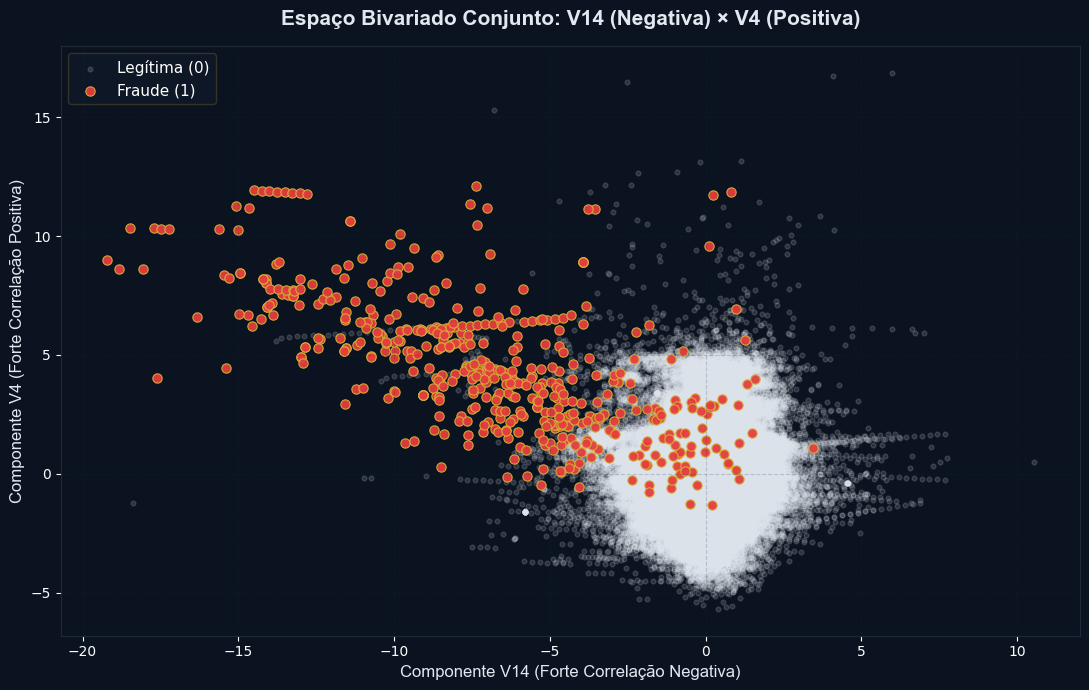

In [24]:
# Dispersão Bivariada Conjunta em Dark HD
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(11, 7), facecolor='#0B1320')
ax.set_facecolor('#0B1320')

# Plotagem das transações legítimas com transparência
legit_sample = df[df['Class'] == 0]
ax.scatter(
    legit_sample['V14'], 
    legit_sample['V4'], 
    color='#E2E8F0', 
    alpha=0.15, 
    s=12, 
    label='Legítima (0)', 
    rasterized=True
)

# Plotagem das fraudes em camada superior com destaque em vermelho e borda dourada
fraud_sample = df[df['Class'] == 1]
ax.scatter(
    fraud_sample['V14'], 
    fraud_sample['V4'], 
    color='#E53E3E', 
    edgecolors='#D4AF37', 
    linewidth=0.8, 
    alpha=0.95, 
    s=45, 
    label='Fraude (1)'
)

ax.set_title("Espaço Bivariado Conjunto: V14 (Negativa) × V4 (Positiva)", 
             fontsize=15, fontweight='bold', color='#E2E8F0', pad=15, family='Arial')
ax.set_xlabel("Componente V14 (Forte Correlação Negativa)", fontsize=12, color='#E2E8F0', family='Arial')
ax.set_ylabel("Componente V4 (Forte Correlação Positiva)", fontsize=12, color='#E2E8F0', family='Arial')

ax.legend(
    loc='upper left', 
    framealpha=0.2, 
    facecolor='#1E293B', 
    edgecolor='#D4AF37',
    fontsize=11
)

ax.grid(True, linestyle='--', alpha=0.2, color='#1E293B')
for spine in ax.spines.values():
    spine.set_color('#1E293B')

plt.tight_layout()
plt.show()


**💡 Análise da Dinâmica Conjunta:**  
Observa-se uma concentração nítida das transações fraudulentas na região de **`V14` muito baixo (< -4)** e **`V4` elevado (> 2)**.  
Contudo, a fronteira entre as classes é curvilínea e irregular: modelos lineares simples (como Regressão Logística) tendem a apresentar alto índice de falsos positivos nessa região de transição, o que justifica e antecipa a superioridade de comitês de árvores (*Random Forest* e *XGBoost*).


## 7. Diagnóstico de Outliers e Impacto nas Fraudes Reais

As variáveis com forte correlação negativa (`V14`, `V12`, `V10`, `V17`) e positiva (`V11`, `V4`) são os principais separadores entre legítimas e fraudulentas.  
Agora é analisado os boxplots comparativos para avaliar a presença de ruídos extremos.


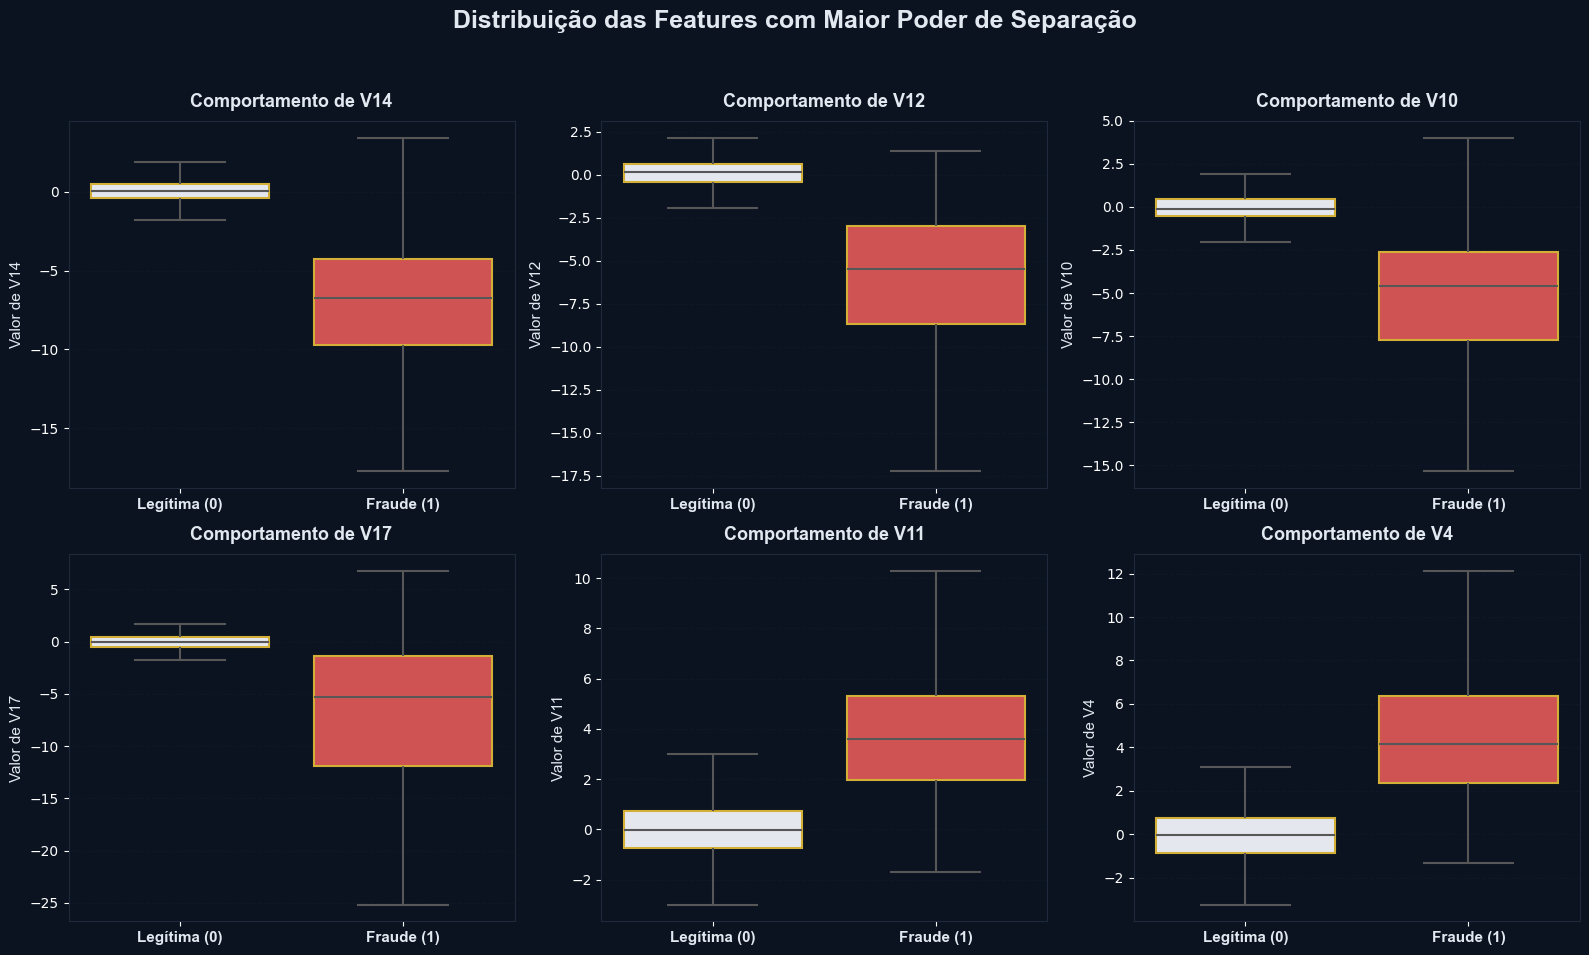

In [25]:
# Painel de Boxplots das Variáveis Mais Separadoras
selected_features = ['V14', 'V12', 'V10', 'V17', 'V11', 'V4']
df_plot = df.copy()
df_plot['Class_Name'] = df_plot['Class'].map({0: 'Legítima (0)', 1: 'Fraude (1)'})

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor='#0B1320')
fig.suptitle("Distribuição das Features com Maior Poder de Separação", 
             fontsize=18, fontweight='bold', color='#E2E8F0', family='Arial', y=0.98)

palette = {'Legítima (0)': '#E2E8F0', 'Fraude (1)': '#E53E3E'}

for ax, feat in zip(axes.ravel(), selected_features):
    ax.set_facecolor('#0B1320')
    
    # Oculta os pontos individuais para manter o visual limpo, rápido e focado nos quartis
    sns.boxplot(
        data=df_plot,
        x='Class_Name',
        y=feat,
        hue='Class_Name',
        palette=palette,
        legend=False,
        showfliers=False,
        linewidth=1.5,
        ax=ax
    )
    
    for patch in ax.patches:
        patch.set_edgecolor('#D4AF37')
        
    ax.set_title(f"Comportamento de {feat}", fontsize=13, fontweight='bold', color='#E2E8F0', pad=10, family='Arial')
    ax.set_xlabel("", fontsize=11)
    ax.set_ylabel(f"Valor de {feat}", fontsize=11, color='#E2E8F0', family='Arial')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Legítima (0)', 'Fraude (1)'], color='#E2E8F0', fontsize=11, fontweight='bold', family='Arial')
    
    ax.yaxis.grid(True, linestyle='--', alpha=0.2, color='#1E293B')
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_color('#1E293B')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

del df_plot


In [26]:
# Auditoria de outliers usando detector modular via IQR
iqr_stats = detect_outliers_iqr(df, features=['V14', 'V12', 'V10', 'V17'], factor=2.5)

audit_df = pd.DataFrame(iqr_stats).T[['lower_bound', 'upper_bound', 'total_outliers', 'outliers_fraud', 'outliers_legit']]
audit_df.columns = ['Limite Inferior', 'Limite Superior', 'Total Outliers', 'Outliers em Fraudes', 'Outliers em Legítimas']

total_frauds_base = (df['Class'] == 1).sum()
audit_df['% Fraudes Atingidas'] = (audit_df['Outliers em Fraudes'] / total_frauds_base) * 100

audit_formatted = audit_df.copy()
audit_formatted['Limite Inferior'] = audit_formatted['Limite Inferior'].apply(lambda x: f"{x:,.3f}".replace(',', '_').replace('.', ',').replace('_', '.'))
audit_formatted['Limite Superior'] = audit_formatted['Limite Superior'].apply(lambda x: f"{x:,.3f}".replace(',', '_').replace('.', ',').replace('_', '.'))
audit_formatted['Total Outliers'] = audit_formatted['Total Outliers'].apply(lambda x: f"{x:_}".replace('_', '.'))
audit_formatted['Outliers em Fraudes'] = audit_formatted['Outliers em Fraudes'].apply(lambda x: f"{x:_}".replace('_', '.'))
audit_formatted['Outliers em Legítimas'] = audit_formatted['Outliers em Legítimas'].apply(lambda x: f"{x:_}".replace('_', '.'))
audit_formatted['% Fraudes Atingidas'] = audit_formatted['% Fraudes Atingidas'].apply(lambda x: f"{x:.2f}%".replace('.', ','))

styled_audit = audit_formatted.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1E293B'), ('color', '#E2E8F0'), ('font-family', 'Arial'), ('font-size', '13px'), ('text-align', 'center'), ('border', '1px solid #334155')]},
    {'selector': 'td', 'props': [('background-color', '#0B1320'), ('color', '#E2E8F0'), ('font-family', 'Arial'), ('font-size', '13px'), ('text-align', 'center'), ('border', '1px solid #1E293B')]},
    {'selector': 'caption', 'props': [('caption-side', 'top'), ('color', '#E2E8F0'), ('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding-bottom', '10px')]}
]).set_properties(**{
    'font-weight': 'bold'
}, subset=['Outliers em Fraudes', '% Fraudes Atingidas']).set_caption("Auditoria da Remoção Potencial de Outliers (Fator IQR = 2.5)")

display(styled_audit)


,Limite Inferior,Limite Superior,Total Outliers,Outliers em Fraudes,Outliers em Legítimas,% Fraudes Atingidas
V14,"-2,722","2,790",3.897.0,414.0,3.483.0,"84,15%"
V12,"-2,965","3,178",3.540.0,369.0,3.171.0,"75,00%"
V10,"-3,009","2,927",4.124.0,347.0,3.777.0,"70,53%"
V17,"-2,692","2,608",2.348.0,367.0,1.981.0,"74,59%"


**⚠️ Alerta Crítico sobre Remoção de Outliers em Fraude:**  
É notável que ao aplicar um corte de IQR estrito nas variáveis correlacionadas (`V14`, `V12`), várias transações fraudulentas caem na zona de cauda externa.  
**Conclusão Prática:** Se for aplicado remoção agressiva de outliers indiscriminadamente, **será eliminado as próprias fraudes que é buscado detectar!**  
Portanto, no pipeline de modelagem, qualquer filtragem via IQR deve:
1. Ser aplicada **exclusivamente sobre o conjunto de treino** (jamais no teste).
2. Utilizar um multiplicador conservador apenas para remover anomalias aberrantes que prejudicariam os hiperplanos da Regressão Logística.

---

## 8. Diretrizes e Próximos Passos para a Modelagem Preditiva

Com base nas evidências empíricas coletadas neste EDA:
1. **Tratamento de Duplicatas e Prevenção de Leakage:** Monitorar rigorosamente as 1.081 duplicatas durante a partição estratificada de treino e teste, assegurando que o desempenho do modelo seja avaliado sobre transações verdadeiramente inéditas.
2. **Escalonamento Robusto:** `Time` e `Amount` apresentam ordens de grandeza díspares das componentes `V1-V28`. Utilizaremos o `RobustScaler` (baseado em mediana e IQR) para que valores atípicos não distorçam a normalização.
3. **Decisão sobre a Variável `Time`:** Para o pipeline baseline, `Time` será mantido e escalonado diretamente. Em iterações futuras de produção, a conversão para codificação cíclica seno/cosseno de `Hour` representa uma excelente oportunidade de engenharia de atributos.
4. **Estratégias de Balanceamento:** Compararemos Dados Brutos (Baseline), Under-sampling (RUS), Over-sampling (SMOTE) e Ponderação de Classes (`class_weight='balanced'` e `scale_pos_weight`).
5. **Métricas de Sucesso:** A acurácia global é formalmente rejeitada; a performance será conduzida por **PR-AUC**, **Recall**, **Precision** e pela **Simulação de Custo Financeiro em Dólares**.

➡️ *Prosseguir para o notebook `02_ml_model.ipynb` para execução dos pipelines de Machine Learning e simulação de negócios.*
